# Satellite AOD Validation Against AERONET Ground Truth
## Publication-Quality Analysis over Vietnam (2022–2026)

**Objective:** Validate satellite-derived AOD (MODIS, Himawari, VIIRS) against AERONET sun photometer measurements, following NASA validation protocols.

**AERONET Sites:**
- **NGHIA_DO** (Hanoi, 21.048°N, 105.800°E) — urban, North Vietnam
- **Bac_Lieu** (9.28°N, 105.73°E) — rural/coastal, South Vietnam

**Validation Protocol:**
1. Spectral interpolation: AERONET multi-wavelength AOD → 550 nm using Ångström exponent
2. Temporal collocation: satellite overpass matched to AERONET within configurable time window
3. Spatial collocation: satellite data from nearest monitoring station to each AERONET site
4. Metrics: R, R², RMSE, MAE, Bias, Expected Error (EE) envelope analysis
5. Sensitivity: time window, L2 vs L3 comparison

**References:**
- Levy et al. (2013) — MODIS Collection 6 AOD validation
- Sayer et al. (2019) — VIIRS Deep Blue validation
- Yoshida et al. (2018) — Himawari-8 AHI aerosol validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
import glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.figsize': (8, 7),
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
})

print('Imports OK')

Imports OK


In [2]:
# === Paths ===
STATIONS_PATH = '/home/work1/projects/Air_Quality/Masterdata/envisoft_27_stations.csv'
AERONET_SITES_PATH = '/home/work1/projects/Air_Quality/Masterdata/AERONET_sites.csv'
AERONET_L10_DIR = '/home/slow_data/Air_Quality/AERONET/10/'
AERONET_L20_DIR = '/home/slow_data/Air_Quality/AERONET/20/'
MODIS_DIR = '/home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v3/'
HIMAWARI_L3_DIR = '/home/slow_data/Air_Quality/Himawari/station_aod_v3/L3/'
HIMAWARI_L2_DIR = '/home/slow_data/Air_Quality/Himawari/station_aod_v3/L2/'
VIIRS_L2_PATH = '/home/slow_data/Air_Quality/VIIRS/output/viirs_aod_L2_NOAA20_nearest_filtered.csv'
VIIRS_L3_PATH = '/home/slow_data/Air_Quality/VIIRS/output/viirs_aod_D3_NOAA20.csv'

# === Parameters ===
TIME_TOLERANCE = '30min'        # ±30 min for satellite-AERONET matching
MAX_STATION_DIST_KM = 50       # max distance from AERONET site to satellite station
AOD_MAX = 5.0
AOD_MIN = -0.05
HIMAWARI_WAVELENGTH = 500
TARGET_WAVELENGTH = 550

# === AERONET spectral interpolation ===
# AOD_550 = AOD_500 * (550/500)^(-AE_440_870)
AERONET_REF_WAVELENGTH = 500   # nm
AERONET_AE_COLUMN = '440-870_Angstrom_Exponent'

# === Expected Error envelope (MODIS standard) ===
# EE = ±(0.05 + 0.15 * AOD_AERONET)
EE_OFFSET = 0.05
EE_SLOPE = 0.15

print('Configuration loaded')
print(f'Time tolerance: ±{TIME_TOLERANCE}')
print(f'Max station distance: {MAX_STATION_DIST_KM} km')

Configuration loaded
Time tolerance: ±30min
Max station distance: 50 km


In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Compute great-circle distance in km between two points."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def compute_metrics(x, y):
    """Compute comprehensive validation metrics."""
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = np.asarray(x)[mask], np.asarray(y)[mask]
    n = len(x)
    if n < 5:
        return None
    slope, intercept, r, p, se = stats.linregress(x, y)
    diff = y - x
    rmse = np.sqrt(np.mean(diff**2))
    mae = np.mean(np.abs(diff))
    bias = np.mean(diff)
    rel_bias = 100 * bias / np.mean(x) if np.mean(x) != 0 else np.nan
    ee = EE_OFFSET + EE_SLOPE * np.abs(x)
    pct_ee = 100 * np.sum(np.abs(diff) <= ee) / n
    pct_above = 100 * np.sum(diff > ee) / n
    pct_below = 100 * np.sum(diff < -ee) / n
    return {'N': n, 'R': round(r, 4), 'R2': round(r**2, 4),
            'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'Bias': round(bias, 4), 'RelBias%': round(rel_bias, 2),
            'Slope': round(slope, 4), 'Intercept': round(intercept, 4),
            '%EE': round(pct_ee, 1), '%Above': round(pct_above, 1), '%Below': round(pct_below, 1)}

def validation_scatter_ee(aod_aeronet, aod_sat, xlabel, ylabel, title, ax=None):
    """Scatter plot with EE envelope for AERONET validation."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    m = compute_metrics(aod_aeronet, aod_sat)
    if m is None:
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center')
        return None

    mask = np.isfinite(aod_aeronet) & np.isfinite(aod_sat)
    xv = np.asarray(aod_aeronet)[mask]
    yv = np.asarray(aod_sat)[mask]

    if len(xv) > 100:
        ax.hexbin(xv, yv, gridsize=30, mincnt=1, cmap='YlOrRd', linewidths=0.2)
    else:
        ax.scatter(xv, yv, s=25, alpha=0.6, c='steelblue', edgecolors='white', linewidth=0.5, zorder=3)

    vmax = max(np.percentile(xv, 99), np.percentile(yv, 99)) * 1.15
    lims = [0, vmax]
    ax.plot(lims, lims, 'k-', lw=1.5, label='1:1', zorder=4)

    # EE envelope
    x_ee = np.linspace(0, vmax, 100)
    ee_upper = x_ee + EE_OFFSET + EE_SLOPE * x_ee
    ee_lower = x_ee - EE_OFFSET - EE_SLOPE * x_ee
    ax.fill_between(x_ee, ee_lower, ee_upper, alpha=0.15, color='blue', label=f'EE (\u00b1{EE_OFFSET}+{EE_SLOPE}\u00d7AOD)')
    ax.plot(x_ee, ee_upper, 'b--', lw=0.8)
    ax.plot(x_ee, ee_lower, 'b--', lw=0.8)

    # Regression
    xfit = np.array(lims)
    ax.plot(xfit, m['Slope'] * xfit + m['Intercept'], 'r-', lw=1.5, zorder=5,
            label=f"y = {m['Slope']:.3f}x + {m['Intercept']:.3f}")

    txt = (f"N = {m['N']}\n"
           f"R\u00b2 = {m['R2']:.3f}\n"
           f"RMSE = {m['RMSE']:.3f}\n"
           f"MAE = {m['MAE']:.3f}\n"
           f"Bias = {m['Bias']:.4f}\n"
           f"%EE = {m['%EE']:.1f}%\n"
           f"Above/Below = {m['%Above']:.0f}% / {m['%Below']:.0f}%")
    ax.text(0.05, 0.95, txt, transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.4'))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim(lims)
    ax.set_ylim([max(-0.1, ee_lower.min()), vmax])
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    return m

print('Helper functions defined')

Helper functions defined


---
## 1. Load and Process AERONET Data

### Spectral Interpolation to 550 nm

AERONET sun photometers do not directly measure at 550 nm. We interpolate from 500 nm using the Ångström exponent (440–870 nm):

$$\tau_{550} = \tau_{500} \times \left(\frac{550}{500}\right)^{-\alpha_{440-870}}$$

where $\tau$ is AOD and $\alpha$ is the Ångström exponent.

In [4]:
# Load AERONET all-points (Level 10)
aeronet_files_l10 = glob.glob(AERONET_L10_DIR + '*.csv')
aeronet_l10_list = []
for f in aeronet_files_l10:
    df = pd.read_csv(f, parse_dates=['datetime'])
    aeronet_l10_list.append(df)
aeronet_l10 = pd.concat(aeronet_l10_list, ignore_index=True)

# Load AERONET daily (Level 20)
aeronet_files_l20 = glob.glob(AERONET_L20_DIR + '*.csv')
aeronet_l20_list = []
for f in aeronet_files_l20:
    df = pd.read_csv(f, parse_dates=['datetime'])
    aeronet_l20_list.append(df)
aeronet_l20 = pd.concat(aeronet_l20_list, ignore_index=True)

print(f'AERONET L10 (all-points): {len(aeronet_l10)} records')
print(f'AERONET L20 (daily avg): {len(aeronet_l20)} records')
print(f'Sites: {aeronet_l10["site"].unique()}')

# Interpolate to 550 nm
for df_name, df in [('L10', aeronet_l10), ('L20', aeronet_l20)]:
    ae = df[AERONET_AE_COLUMN]
    aod_500 = df['AOD_500nm']

    valid = aod_500.notna() & ae.notna() & (ae > -0.5) & (ae < 3.0) & (aod_500 > AOD_MIN)
    df['AOD_550'] = np.where(
        valid,
        aod_500 * (TARGET_WAVELENGTH / AERONET_REF_WAVELENGTH) ** (-ae),
        np.nan
    )
    n_valid = df['AOD_550'].notna().sum()
    print(f'{df_name}: {n_valid}/{len(df)} records with valid AOD_550 ({100*n_valid/len(df):.1f}%)')

# Summary per site
for site in aeronet_l10['site'].unique():
    sub = aeronet_l10[aeronet_l10['site'] == site]
    valid = sub['AOD_550'].dropna()
    print(f'\n{site}:')
    print(f'  Records with AOD_550: {len(valid)}')
    print(f'  Date range: {sub["datetime"].min()} to {sub["datetime"].max()}')
    print(f'  AOD_550 mean: {valid.mean():.3f}, median: {valid.median():.3f}, std: {valid.std():.3f}')

AERONET L10 (all-points): 29215 records
AERONET L20 (daily avg): 1148 records
Sites: ['NGHIA_DO' 'Bac_Lieu']
L10: 28868/29215 records with valid AOD_550 (98.8%)
L20: 1144/1148 records with valid AOD_550 (99.7%)

NGHIA_DO:
  Records with AOD_550: 13173
  Date range: 2022-02-23 13:56:22 to 2026-04-23 17:35:51
  AOD_550 mean: 0.694, median: 0.486, std: 0.559

Bac_Lieu:
  Records with AOD_550: 15695
  Date range: 2022-04-21 06:38:46 to 2025-08-22 10:16:10
  AOD_550 mean: 0.212, median: 0.160, std: 0.187


In [5]:
# Quality control: filter valid AERONET observations
aeronet = aeronet_l10[
    (aeronet_l10['AOD_550'].notna()) &
    (aeronet_l10['AOD_550'] > AOD_MIN) &
    (aeronet_l10['AOD_550'] < AOD_MAX)
].copy()

# Load AERONET site coordinates
aeronet_sites = pd.read_csv(AERONET_SITES_PATH)
print('AERONET sites:')
display(aeronet_sites)

# Verify coordinates from data
for site in aeronet['site'].unique():
    sub = aeronet[aeronet['site'] == site]
    print(f'{site}: lat={sub["site_lat"].iloc[0]}, lon={sub["site_lon"].iloc[0]}, N={len(sub)}')

AERONET sites:


,stationId,stationName,latitude,longitude,Location
0,1,Bac_Giang,21.291,106.225,"Bac Giang, Vietnam"
1,2,Bac_Lieu,9.280,105.730,"Bac Lieu, Vietnam"
2,3,Bach_Long_Vy,20.133,107.733,"Bach Long Vy, Vietnam"
3,4,NGHIA_DO,21.048,105.800,"Nghia Do, Vietnam"
4,5,NhaTrang,12.205,109.206,"Nha Trang, Vietnam"
5,6,Red_River_Delta,20.729,106.128,"Red River, Vietnam"
6,7,Son_La,21.332,103.905,"Son La, Vietnam"
7,8,Yen_Bai,21.705,104.869,"Yen Bai, Vietnam"


NGHIA_DO: lat=21.048, lon=105.8, N=13173
Bac_Lieu: lat=9.28, lon=105.73, N=15695


---
## 2. Spatial Collocation: Find Nearest Satellite Stations

Satellite AOD was extracted at 27 EnviSoft monitoring stations (+ additional stations from the full 123-station network). For each AERONET site, we identify the nearest satellite extraction point(s) and quantify the spatial separation.

In [6]:
# Load all station metadata
stations_27 = pd.read_csv(STATIONS_PATH)
stations_27['stationId'] = stations_27['stationId'].astype(str)

# For each AERONET site, find nearest EnviSoft stations
aeronet_station_map = {}

for _, asite in aeronet_sites.iterrows():
    site_name = asite['stationName']
    site_lat = asite['latitude']
    site_lon = asite['longitude']

    # Compute distance to all 27 stations
    stations_27['dist_km'] = stations_27.apply(
        lambda row: haversine_km(site_lat, site_lon, row['latitude'], row['longitude']), axis=1
    )

    nearest = stations_27.nsmallest(5, 'dist_km')[['stationId', 'stationName', 'latitude', 'longitude', 'dist_km']]
    print(f'\nAERONET site: {site_name} ({site_lat}, {site_lon})')
    print(f'Nearest EnviSoft stations:')
    display(nearest)

    # Select stations within threshold
    within = nearest[nearest['dist_km'] <= MAX_STATION_DIST_KM]
    if len(within) == 0:
        print(f'  WARNING: No station within {MAX_STATION_DIST_KM} km! Using nearest.')
        within = nearest.head(1)

    aeronet_station_map[site_name] = {
        'aeronet_lat': site_lat,
        'aeronet_lon': site_lon,
        'matched_stations': within[['stationId', 'stationName', 'dist_km']].to_dict('records')
    }

print('\n=== Station Matching Summary ===')
for site, info in aeronet_station_map.items():
    n = len(info['matched_stations'])
    dists = [s['dist_km'] for s in info['matched_stations']]
    print(f'{site}: {n} station(s), distances: {[round(d, 1) for d in dists]} km')


AERONET site: Bac_Giang (21.291, 106.225)
Nearest EnviSoft stations:


,stationId,stationName,latitude,longitude,dist_km
16,31388868531618872623864101418,Hải Dương: UBND TP. Hải Dương - 106 Đường Trần...,20.9381,106.336,40.895022
22,28560877461938780203765592307,Hà Nội: 556 Nguyễn Văn Cừ (KK),21.0491,105.883,44.509219
5,31390903576425084107499649578,Hà Nội: ĐHBK cổng Parabol đường Giải Phóng (KK),21.0052,105.842,50.868105
6,31390908889087377344742439468,Hà Nội: Công viên Nhân Chính - Khuất Duy Tiến ...,21.0031,105.795,54.894844
9,31390921469766835629621918251,Hưng Yên: số 437 Nguyễn Văn Linh - Tp Hưng Yên...,20.6618,106.059,72.055422



AERONET site: Bac_Lieu (9.28, 105.73)
Nearest EnviSoft stations:


,stationId,stationName,latitude,longitude,dist_km
23,30991938797551443885460120607,"Sóc Trăng: Sở TNMT - 16 Hùng Vương, P.6, Tp. S...",9.61358,105.968,45.357923
21,29098319146067624969113973428,"Trà Vinh: xã Đông Hải, huyện Duyên Hải (KK)",9.57555,106.488,89.406228
20,30921862678974937849512304668,Trà Vinh: Tp. Trà Vinh (KK),9.92389,106.340,97.973847
24,30668578626453200136007481288,"Vĩnh Long: UBND tỉnh, đường Hoàng Thái Hiếu (KK)",10.25130,105.947,110.590425
11,31390932574706768021562473002,Long An: UBND Tp Tân An - 76 Hùng Vương - P.2 ...,10.53910,106.405,158.328628



AERONET site: Bach_Long_Vy (20.133, 107.733)
Nearest EnviSoft stations:


...


AERONET site: Son_La (21.332, 103.905)
Nearest EnviSoft stations:


,stationId,stationName,latitude,longitude,dist_km
0,28505268571336961948594948504,Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK),21.3385,105.367,151.427053
6,31390908889087377344742439468,Hà Nội: Công viên Nhân Chính - Khuất Duy Tiến ...,21.0031,105.795,199.360367
5,31390903576425084107499649578,Hà Nội: ĐHBK cổng Parabol đường Giải Phóng (KK),21.0052,105.842,204.109967
22,28560877461938780203765592307,Hà Nội: 556 Nguyễn Văn Cừ (KK),21.0491,105.883,207.468776
4,31388883344354363840031242796,Hà Nam: Công Viên Nam Cao - P.Quang Trung - TP...,20.5360,105.916,226.830716



AERONET site: Yen_Bai (21.705, 104.869)
Nearest EnviSoft stations:


,stationId,stationName,latitude,longitude,dist_km
0,28505268571336961948594948504,Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK),21.3385,105.367,65.684876
6,31390908889087377344742439468,Hà Nội: Công viên Nhân Chính - Khuất Duy Tiến ...,21.0031,105.795,123.643089
5,31390903576425084107499649578,Hà Nội: ĐHBK cổng Parabol đường Giải Phóng (KK),21.0052,105.842,127.311750
22,28560877461938780203765592307,Hà Nội: 556 Nguyễn Văn Cừ (KK),21.0491,105.883,127.839075
9,31390921469766835629621918251,Hưng Yên: số 437 Nguyễn Văn Linh - Tp Hưng Yên...,20.6618,106.059,169.345200



=== Station Matching Summary ===
Bac_Giang: 2 station(s), distances: [40.9, 44.5] km
Bac_Lieu: 1 station(s), distances: [45.4] km
Bach_Long_Vy: 1 station(s), distances: [108.5] km
NGHIA_DO: 3 station(s), distances: [5.0, 6.5, 8.6] km
NhaTrang: 1 station(s), distances: [74.0] km
Red_River_Delta: 5 station(s), distances: [10.4, 30.8, 31.7, 37.6, 42.7] km
Son_La: 1 station(s), distances: [151.4] km
Yen_Bai: 1 station(s), distances: [65.7] km


---
## 3. Load Satellite Data at AERONET-Adjacent Stations

In [7]:
# Collect stationIds for all matched stations
matched_ids = set()
matched_names = set()
for site, info in aeronet_station_map.items():
    for s in info['matched_stations']:
        matched_ids.add(s['stationId'])
        matched_names.add(s['stationName'])

print(f'Loading satellite data for {len(matched_ids)} matched station(s): {matched_names}')

# --- Load MODIS ---
modis_dfs = []
for f in glob.glob(MODIS_DIR + '*.csv'):
    try:
        df = pd.read_csv(f, parse_dates=['timestamp'], low_memory=False)
        df['stationId'] = df['stationId'].astype(str)
        if df['stationId'].iloc[0] in matched_ids:
            modis_dfs.append(df)
    except:
        pass

if modis_dfs:
    modis = pd.concat(modis_dfs, ignore_index=True)
    modis = modis[
        (modis['Optical_Depth_055'].notna()) &
        (modis['Optical_Depth_055'] >= AOD_MIN) &
        (modis['Optical_Depth_055'] <= AOD_MAX)
    ].copy()
    modis = modis.rename(columns={'timestamp': 'datetime', 'Optical_Depth_055': 'aod_550'})
    modis['station_name'] = modis['stationName']
    print(f'MODIS: {len(modis)} records loaded')
else:
    modis = pd.DataFrame()
    print('MODIS: No data found for matched stations')

# --- Load Himawari L3 ---
hima_l3_dfs = []
for f in glob.glob(HIMAWARI_L3_DIR + '*.csv'):
    try:
        df = pd.read_csv(f, parse_dates=['timestamp'], low_memory=False)
        df['stationId'] = df['stationId'].astype(str)
        if df['stationId'].iloc[0] in matched_ids:
            hima_l3_dfs.append(df)
    except:
        pass

if hima_l3_dfs:
    hima_l3 = pd.concat(hima_l3_dfs, ignore_index=True)
    hima_l3 = hima_l3[
        (hima_l3['AOT_Merged_center'].notna()) &
        (hima_l3['AOT_Merged_center'] > AOD_MIN) &
        (hima_l3['AOT_Merged_center'] <= AOD_MAX)
    ].copy()

    # Wavelength correction 500->550 nm
    ae = hima_l3['AE_Merged']
    valid_ae = ae.notna() & (ae > 0) & (ae < 3)
    hima_l3['aod_550'] = np.where(
        valid_ae,
        hima_l3['AOT_Merged_center'] * (TARGET_WAVELENGTH / HIMAWARI_WAVELENGTH) ** (-ae),
        hima_l3['AOT_Merged_center']
    )
    hima_l3 = hima_l3.rename(columns={'timestamp': 'datetime'})
    station_id_to_name = dict(zip(stations_27['stationId'], stations_27['stationName']))
    hima_l3['station_name'] = hima_l3['stationId'].map(station_id_to_name)
    print(f'Himawari L3: {len(hima_l3)} records loaded')
else:
    hima_l3 = pd.DataFrame()
    print('Himawari L3: No data found')

# --- Load Himawari L2 ---
hima_l2_dfs = []
for f in glob.glob(HIMAWARI_L2_DIR + '*.csv'):
    try:
        df = pd.read_csv(f, parse_dates=['timestamp'], low_memory=False)
        df['stationId'] = df['stationId'].astype(str)
        if df['stationId'].iloc[0] in matched_ids:
            hima_l2_dfs.append(df)
    except:
        pass

if hima_l2_dfs:
    hima_l2 = pd.concat(hima_l2_dfs, ignore_index=True)
    hima_l2 = hima_l2[
        (hima_l2['AOT_Merged_center'].notna()) &
        (hima_l2['AOT_Merged_center'] > AOD_MIN) &
        (hima_l2['AOT_Merged_center'] <= AOD_MAX)
    ].copy()
    ae = hima_l2['AE_Merged']
    valid_ae = ae.notna() & (ae > 0) & (ae < 3)
    hima_l2['aod_550'] = np.where(
        valid_ae,
        hima_l2['AOT_Merged_center'] * (TARGET_WAVELENGTH / HIMAWARI_WAVELENGTH) ** (-ae),
        hima_l2['AOT_Merged_center']
    )
    hima_l2 = hima_l2.rename(columns={'timestamp': 'datetime'})
    hima_l2['station_name'] = hima_l2['stationId'].map(station_id_to_name)
    print(f'Himawari L2: {len(hima_l2)} records loaded')
else:
    hima_l2 = pd.DataFrame()
    print('Himawari L2: No data found')

# --- Load VIIRS ---
viirs_l2 = pd.read_csv(VIIRS_L2_PATH, parse_dates=['datetime'])
viirs_l2 = viirs_l2.rename(columns={'station': 'station_name', 'aod': 'aod_550'})
viirs_l2 = viirs_l2[
    (viirs_l2['aod_550'].notna()) &
    (viirs_l2['aod_550'] >= AOD_MIN) &
    (viirs_l2['aod_550'] <= AOD_MAX) &
    (viirs_l2['qa'] >= viirs_l2['qa_threshold'])
].copy()
viirs_l2_matched = viirs_l2[viirs_l2['station_name'].isin(matched_names)]
print(f'VIIRS L2 (matched stations): {len(viirs_l2_matched)} records')

viirs_l3 = pd.read_csv(VIIRS_L3_PATH, parse_dates=['datetime'])
viirs_l3 = viirs_l3.rename(columns={'station': 'station_name', 'aod_mean': 'aod_550'})
viirs_l3 = viirs_l3[
    (viirs_l3['aod_550'].notna()) &
    (viirs_l3['aod_550'] >= AOD_MIN) &
    (viirs_l3['aod_550'] <= AOD_MAX)
].copy()
viirs_l3_matched = viirs_l3[viirs_l3['station_name'].isin(matched_names)]
print(f'VIIRS L3 (matched stations): {len(viirs_l3_matched)} records')

Loading satellite data for 11 matched station(s): {'Hà Nam: Công Viên Nam Cao - P.Quang Trung - TP. Phủ Lý (KK)', 'Ninh Thuận: Công viên (bến xe cũ) - Đ. Thống Nhất - P. Thanh Sơn - TP Phan Rang (KK)', 'Thái Bình: Cầu Thái Bình - Đ. Trần Thái Tông - P. Bồ Xuyên - TP Thái Bình (KK)', 'Quảng Ninh: Trung tâm văn hóa thể thao Cẩm Phả, đường Trần Phú, phường Cẩm Trung (KK)', 'Sóc Trăng: Sở TNMT - 16 Hùng Vương, P.6, Tp. Sóc Trăng (KK)', 'Hà Nội: ĐHBK cổng Parabol đường Giải Phóng (KK)', 'Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK)', 'Hà Nội: 556 Nguyễn Văn Cừ (KK)', 'Hưng Yên: số 437 Nguyễn Văn Linh - Tp Hưng Yên (KK)', 'Hải Dương: UBND TP. Hải Dương - 106 Đường Trần Hưng Đạo (KK)', 'Hà Nội: Công viên Nhân Chính - Khuất Duy Tiến (KK)'}


MODIS: 6683 records loaded
Himawari L3: 6725 records loaded
Himawari L2: No data found
VIIRS L2 (matched stations): 1272 records
VIIRS L3 (matched stations): 6060 records


---
## 4. Temporal Collocation Pipeline

For each AERONET site, match satellite observations from the nearest station(s) within the time tolerance window (±30 min default).

The collocation uses `merge_asof` with nearest-time matching per station. AERONET (with higher temporal resolution) acts as the reference.

In [8]:
def collocate_aeronet_satellite(aeronet_df, sat_df, aeronet_site, matched_station_names,
                                  tolerance=TIME_TOLERANCE, sat_name='Satellite'):
    """Collocate AERONET with satellite data from nearby station(s)."""
    # Filter AERONET for this site
    aero = aeronet_df[aeronet_df['site'] == aeronet_site][['datetime', 'AOD_550', 'site']].copy()
    aero = aero.dropna(subset=['AOD_550']).sort_values('datetime').reset_index(drop=True)

    if len(aero) == 0 or len(sat_df) == 0:
        return pd.DataFrame()

    # Filter satellite for matched stations
    sat = sat_df[sat_df['station_name'].isin(matched_station_names)][['datetime', 'aod_550', 'station_name']].copy()
    sat = sat.dropna(subset=['aod_550'])

    if len(sat) == 0:
        return pd.DataFrame()

    # For each satellite station, merge with AERONET (per-station to ensure sort order)
    all_matched = []
    for stn in matched_station_names:
        sat_stn = sat[sat['station_name'] == stn].sort_values('datetime').reset_index(drop=True)
        if len(sat_stn) == 0:
            continue

        merged = pd.merge_asof(
            sat_stn.rename(columns={'aod_550': f'AOD_{sat_name}'}),
            aero.rename(columns={'AOD_550': 'AOD_AERONET'}),
            on='datetime',
            tolerance=pd.Timedelta(tolerance),
            direction='nearest'
        )
        merged = merged.dropna(subset=['AOD_AERONET'])
        merged['aeronet_site'] = aeronet_site
        all_matched.append(merged)

    if not all_matched:
        return pd.DataFrame()

    result = pd.concat(all_matched, ignore_index=True)
    print(f'  {aeronet_site} x {sat_name}: {len(aero)} AERONET + {len(sat)} sat -> {len(result)} matched pairs')
    return result

# Run collocation for all sensors and sites
# Use tuple keys (sat_name, site) to avoid underscore-splitting issues
collocations = {}
sensors = {
    'MODIS': modis,
    'Himawari_L3': hima_l3,
    'Himawari_L2': hima_l2,
    'VIIRS_L2': viirs_l2_matched,
    'VIIRS_L3': viirs_l3_matched,
}

for sat_name, sat_df in sensors.items():
    if len(sat_df) == 0:
        print(f'{sat_name}: No data available')
        continue
    print(f'\n=== {sat_name} ===')
    for aeronet_site, info in aeronet_station_map.items():
        matched_names_list = [s['stationName'] for s in info['matched_stations']]
        key = (sat_name, aeronet_site)
        result = collocate_aeronet_satellite(
            aeronet, sat_df, aeronet_site, matched_names_list,
            tolerance=TIME_TOLERANCE, sat_name=sat_name
        )
        if len(result) > 0:
            collocations[key] = result


=== MODIS ===
  Bac_Lieu x MODIS: 15695 AERONET + 631 sat -> 335 matched pairs
  NGHIA_DO x MODIS: 13173 AERONET + 1461 sat -> 710 matched pairs

=== Himawari_L3 ===
  Bac_Lieu x Himawari_L3: 15695 AERONET + 294 sat -> 199 matched pairs
  NGHIA_DO x Himawari_L3: 13173 AERONET + 2138 sat -> 1284 matched pairs
Himawari_L2: No data available

=== VIIRS_L2 ===
  Bac_Lieu x VIIRS_L2: 15695 AERONET + 35 sat -> 25 matched pairs
  NGHIA_DO x VIIRS_L2: 13173 AERONET + 464 sat -> 318 matched pairs

=== VIIRS_L3 ===
  Bac_Lieu x VIIRS_L3: 15695 AERONET + 578 sat -> 126 matched pairs
  NGHIA_DO x VIIRS_L3: 13173 AERONET + 1257 sat -> 270 matched pairs


---
## 5. Validation Results

### Per-Site, Per-Sensor Scatter Plots with Expected Error Envelope

The Expected Error (EE) envelope is defined as:
$$EE = \pm(0.05 + 0.15 \times \tau_{AERONET})$$

This is the standard envelope used in MODIS AOD validation (Levy et al., 2013). The fraction of retrievals falling within this envelope (%EE) is a key quality indicator.

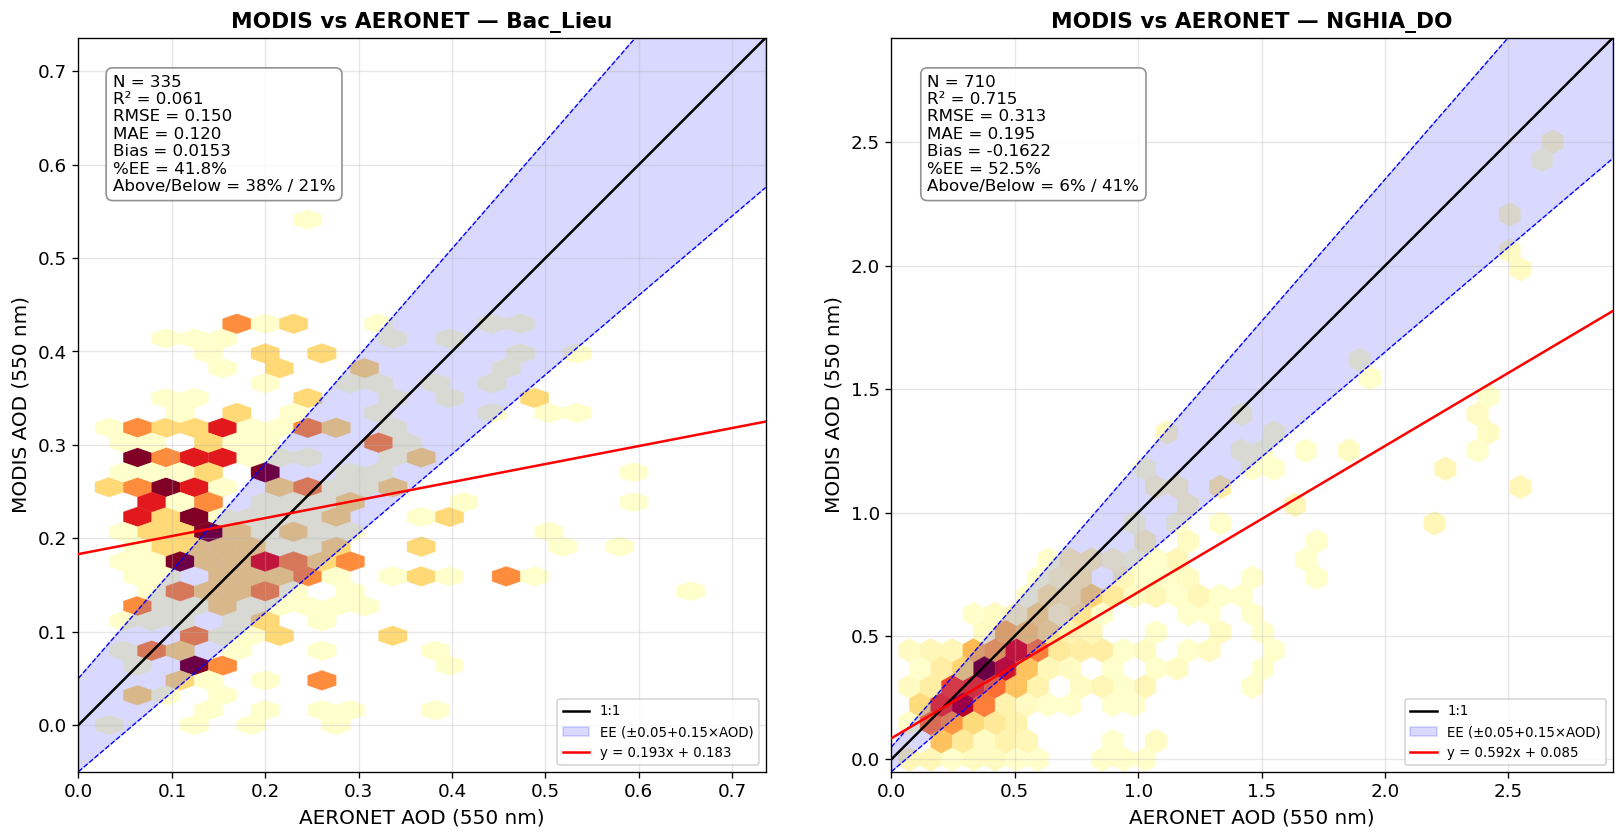

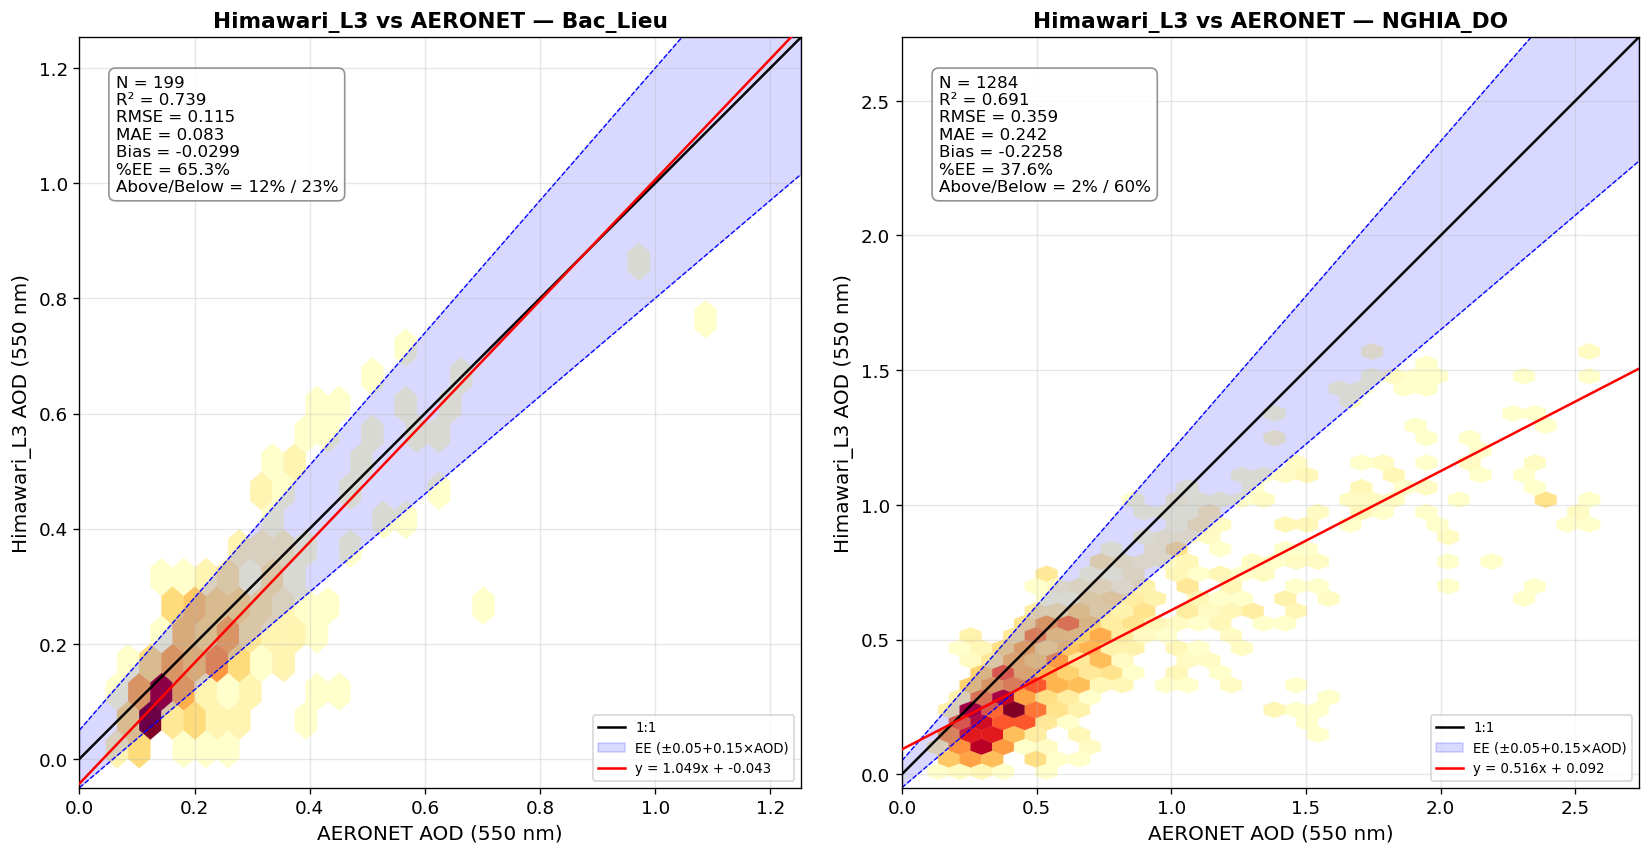

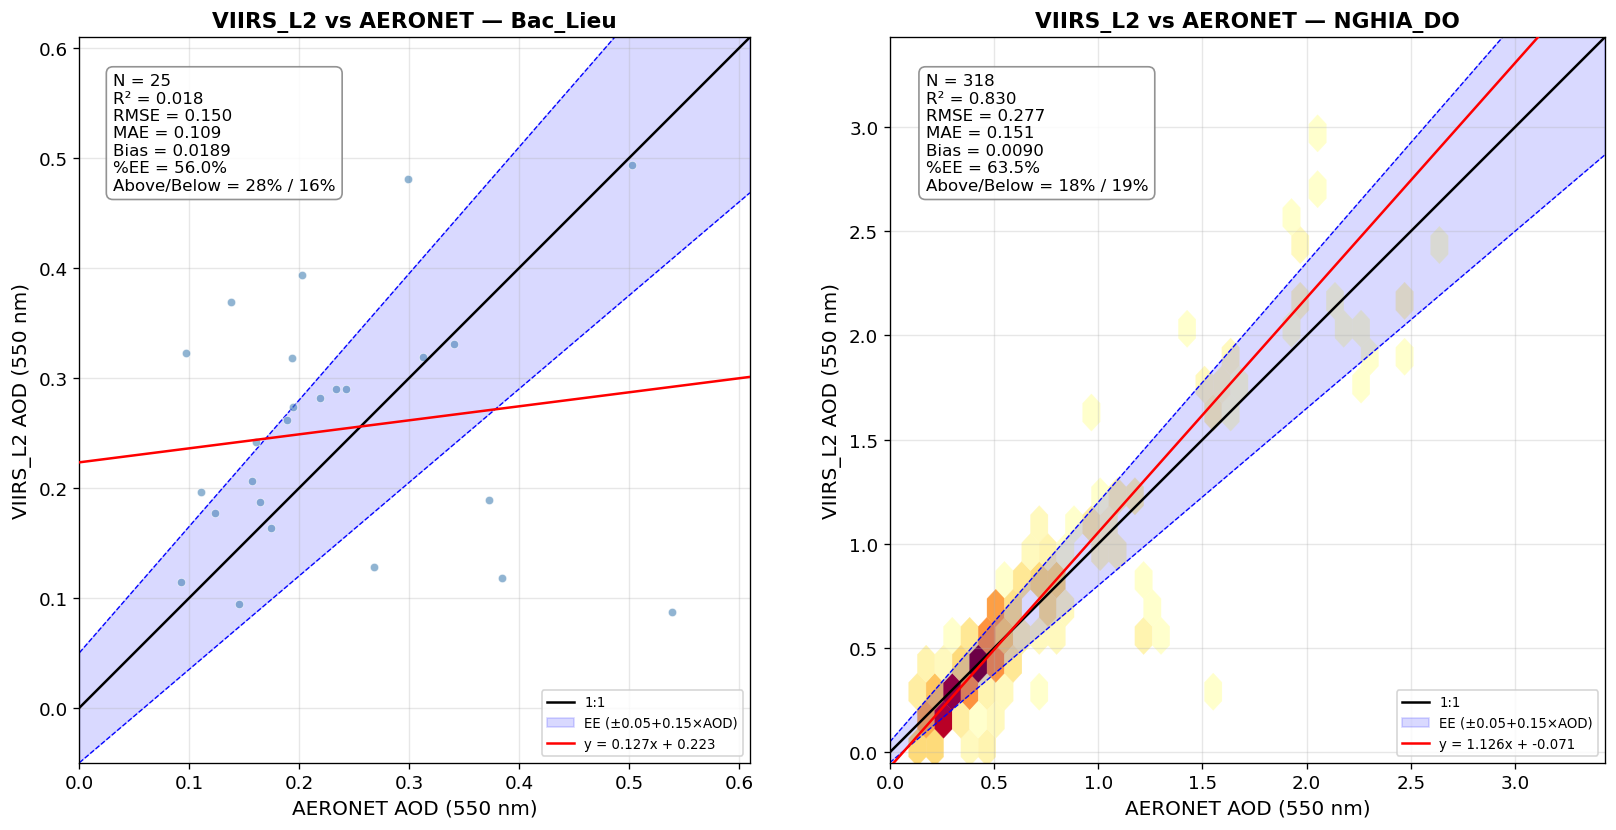

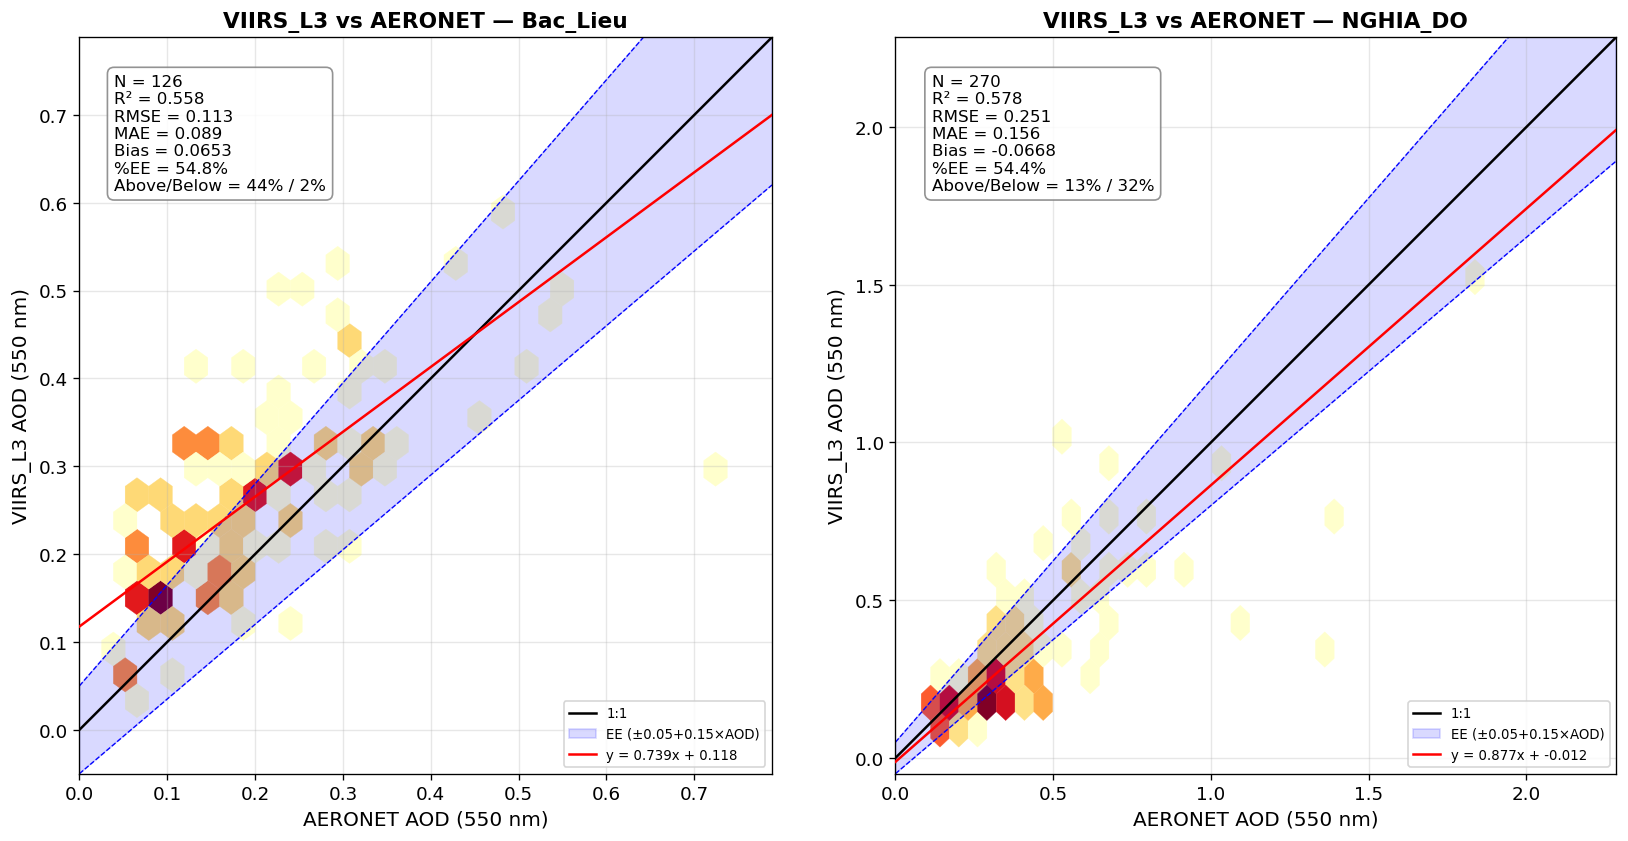


=== Validation Summary ===


,Sensor,Site,N,R,R2,RMSE,MAE,Bias,%EE,Slope,Intercept
0,MODIS,Bac_Lieu,335,0.2476,0.0613,0.1502,0.1199,0.0153,41.8,0.1928,0.1830
1,MODIS,NGHIA_DO,710,0.8457,0.7153,0.3126,0.1949,-0.1622,52.5,0.5923,0.0851
2,Himawari_L3,Bac_Lieu,199,0.8593,0.7385,0.1150,0.0826,-0.0299,65.3,1.0489,-0.0429
3,Himawari_L3,NGHIA_DO,1284,0.8313,0.6911,0.3591,0.2423,-0.2258,37.6,0.5165,0.0922
4,VIIRS_L2,Bac_Lieu,25,0.1355,0.0184,0.1500,0.1088,0.0189,56.0,0.1274,0.2231
5,VIIRS_L2,NGHIA_DO,318,0.9108,0.8295,0.2765,0.1510,0.0090,63.5,1.1263,-0.0714
6,VIIRS_L3,Bac_Lieu,126,0.7470,0.5581,0.1128,0.0888,0.0653,54.8,0.7387,0.1176
7,VIIRS_L3,NGHIA_DO,270,0.7605,0.5784,0.2507,0.1562,-0.0668,54.4,0.8768,-0.0123


In [9]:
# Organize results by sensor
sensor_sites = {}
for (sat, site), df in collocations.items():
    if sat not in sensor_sites:
        sensor_sites[sat] = {}
    sensor_sites[sat][site] = df

# Create scatter plots
all_metrics = []

for sat_name in ['MODIS', 'Himawari_L2', 'Himawari_L3', 'VIIRS_L2', 'VIIRS_L3']:
    if sat_name not in sensor_sites:
        continue
    sites = sensor_sites[sat_name]
    n_sites = len(sites)
    if n_sites == 0:
        continue

    fig, axes = plt.subplots(1, n_sites, figsize=(7 * n_sites, 7), squeeze=False)
    axes = axes[0]

    for i, (site_name, df) in enumerate(sorted(sites.items())):
        m = validation_scatter_ee(
            df['AOD_AERONET'], df[f'AOD_{sat_name}'],
            'AERONET AOD (550 nm)', f'{sat_name} AOD (550 nm)',
            f'{sat_name} vs AERONET — {site_name}',
            ax=axes[i]
        )
        if m:
            m['Sensor'] = sat_name
            m['Site'] = site_name
            all_metrics.append(m)

    plt.tight_layout()
    plt.show()

# Summary table
if all_metrics:
    df_metrics = pd.DataFrame(all_metrics)
    print('\n=== Validation Summary ===')
    display(df_metrics[['Sensor', 'Site', 'N', 'R', 'R2', 'RMSE', 'MAE', 'Bias', '%EE', 'Slope', 'Intercept']])

---
## 6. Error Distribution Analysis

Examine the distribution of satellite–AERONET differences to identify systematic biases and their AOD-dependence.

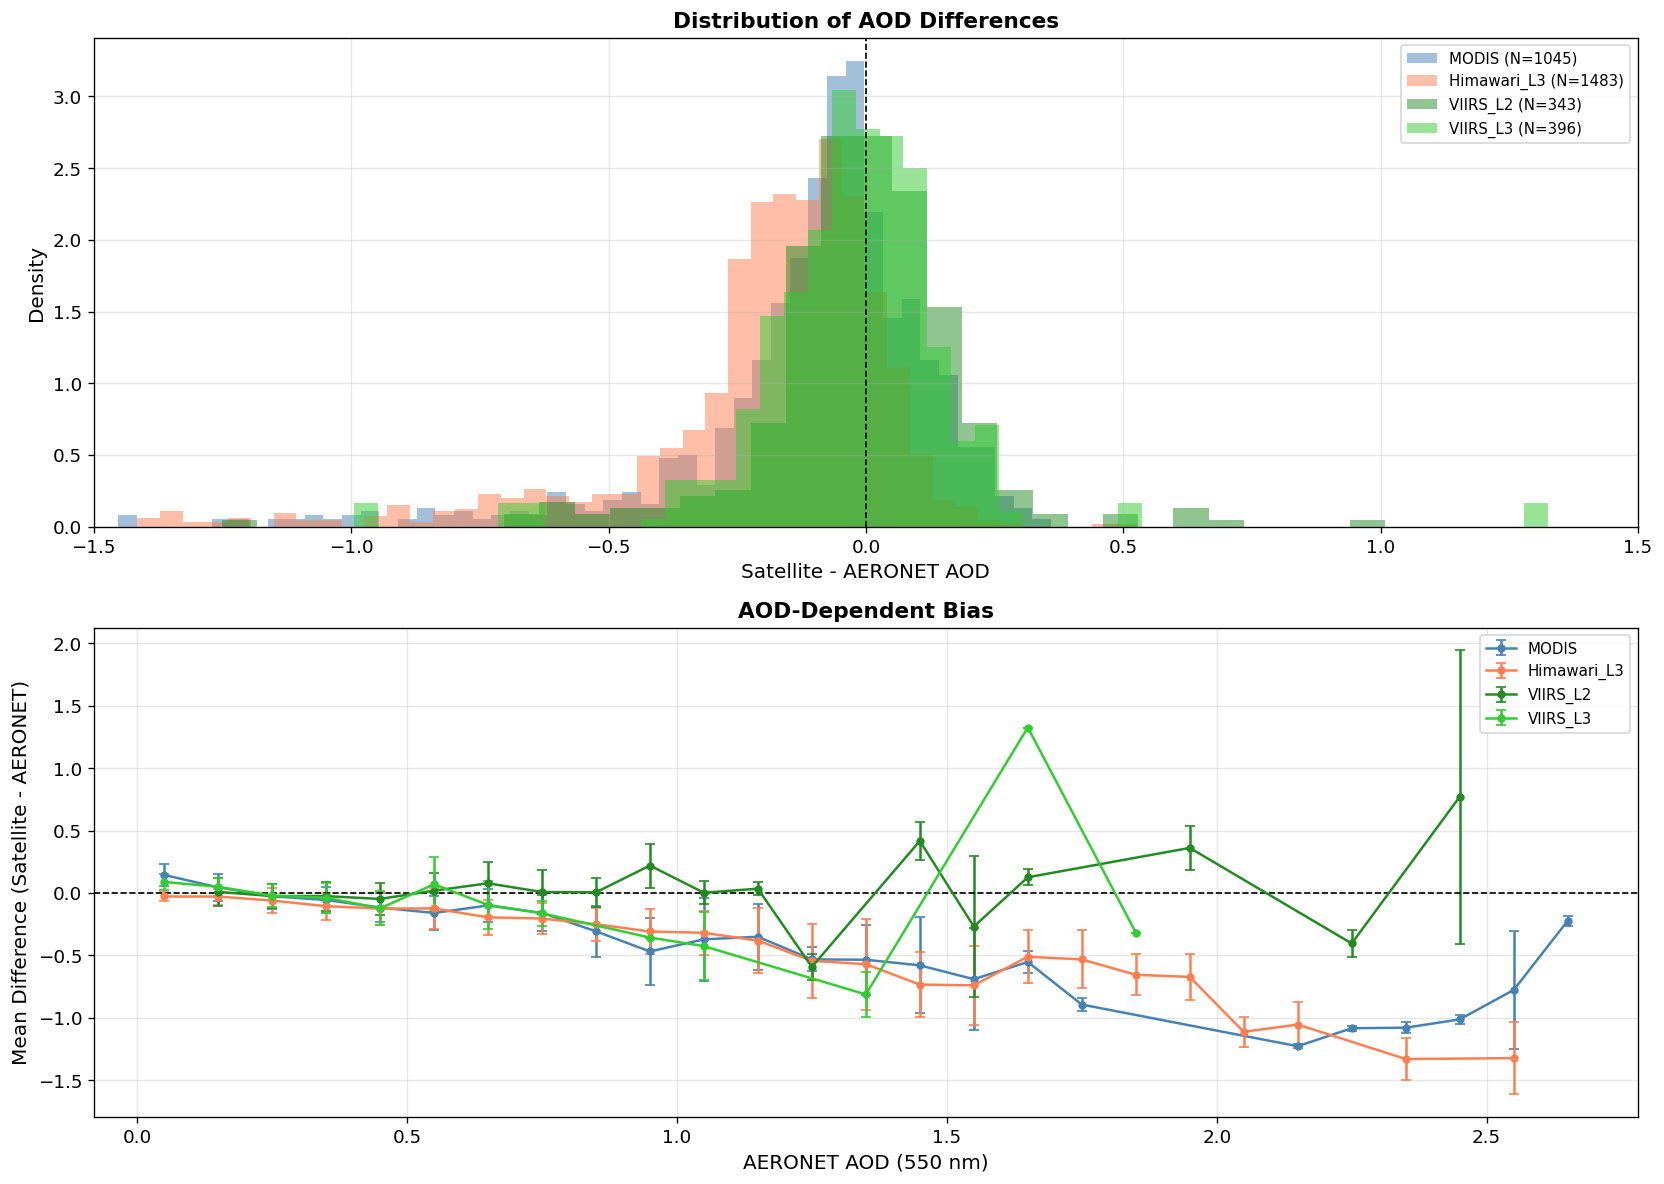

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

colors_map = {
    'MODIS': 'steelblue', 'Himawari_L2': 'darkorange', 'Himawari_L3': 'coral',
    'VIIRS_L2': 'forestgreen', 'VIIRS_L3': 'limegreen'
}

# Panel 1: Histogram of differences
for sat_name, sites in sensor_sites.items():
    all_diffs = []
    for site_name, df in sites.items():
        diff = df[f'AOD_{sat_name}'] - df['AOD_AERONET']
        all_diffs.extend(diff.dropna().tolist())
    if all_diffs:
        axes[0].hist(all_diffs, bins=50, alpha=0.5, label=f'{sat_name} (N={len(all_diffs)})',
                     color=colors_map.get(sat_name, 'gray'), density=True)

axes[0].axvline(0, color='k', ls='--', lw=1)
axes[0].set_xlabel('Satellite - AERONET AOD')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of AOD Differences', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(-1.5, 1.5)
axes[0].grid(True, alpha=0.3)

# Panel 2: Bias vs AOD (AOD-dependent error)
for sat_name, sites in sensor_sites.items():
    all_ref = []
    all_diff = []
    for site_name, df in sites.items():
        ref = df['AOD_AERONET']
        diff = df[f'AOD_{sat_name}'] - df['AOD_AERONET']
        all_ref.extend(ref.dropna().tolist())
        all_diff.extend(diff.dropna().tolist())
    if all_ref:
        ref_arr = np.array(all_ref)
        diff_arr = np.array(all_diff)
        # Bin by AOD
        bins = np.arange(0, max(ref_arr) + 0.1, 0.1)
        bin_centers = []
        bin_means = []
        bin_stds = []
        for j in range(len(bins) - 1):
            mask = (ref_arr >= bins[j]) & (ref_arr < bins[j+1])
            if mask.sum() >= 3:
                bin_centers.append((bins[j] + bins[j+1]) / 2)
                bin_means.append(diff_arr[mask].mean())
                bin_stds.append(diff_arr[mask].std())
        if bin_centers:
            axes[1].errorbar(bin_centers, bin_means, yerr=bin_stds, marker='o', ms=4,
                            capsize=3, label=sat_name, color=colors_map.get(sat_name, 'gray'))

axes[1].axhline(0, color='k', ls='--', lw=1)
axes[1].set_xlabel('AERONET AOD (550 nm)')
axes[1].set_ylabel('Mean Difference (Satellite - AERONET)')
axes[1].set_title('AOD-Dependent Bias', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Time Series Comparison

Compare temporal evolution of AERONET and satellite AOD at each validation site.

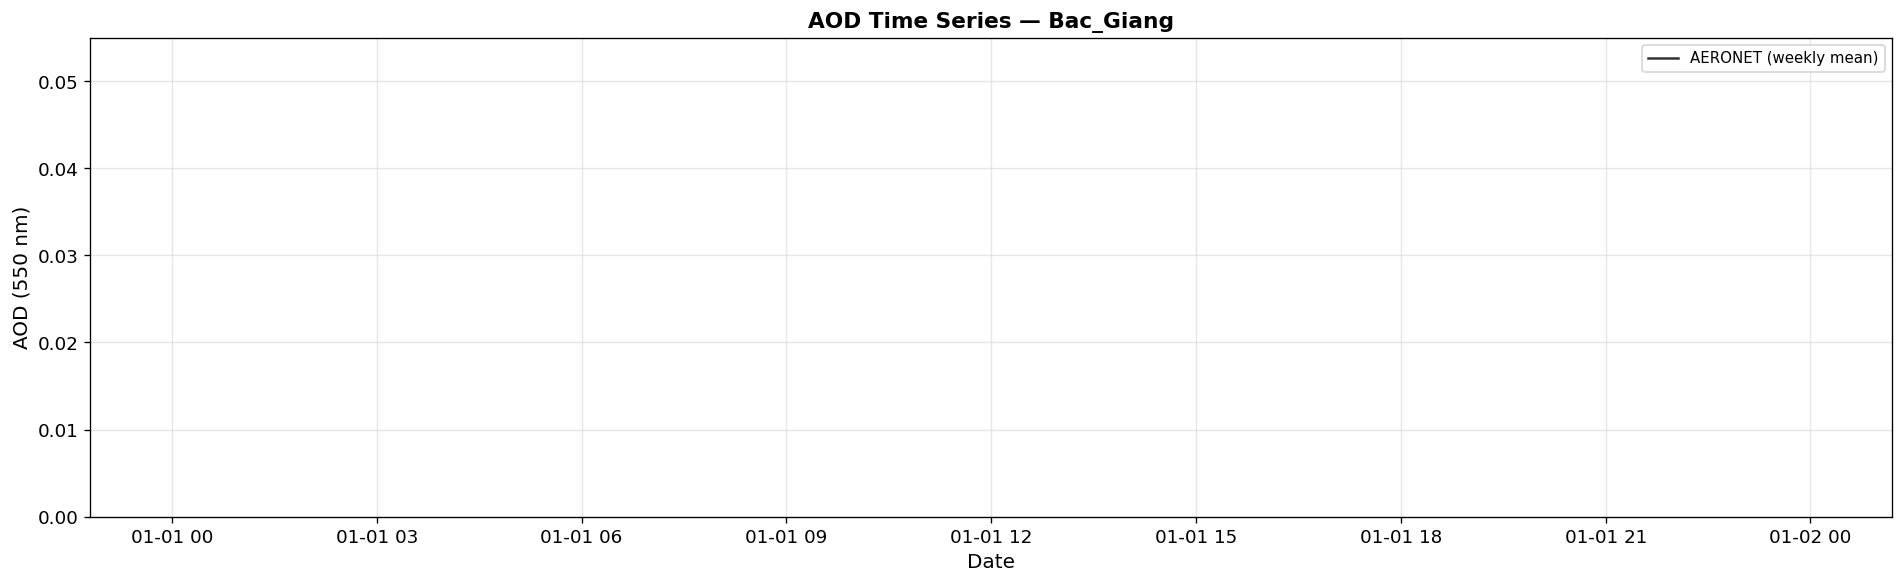

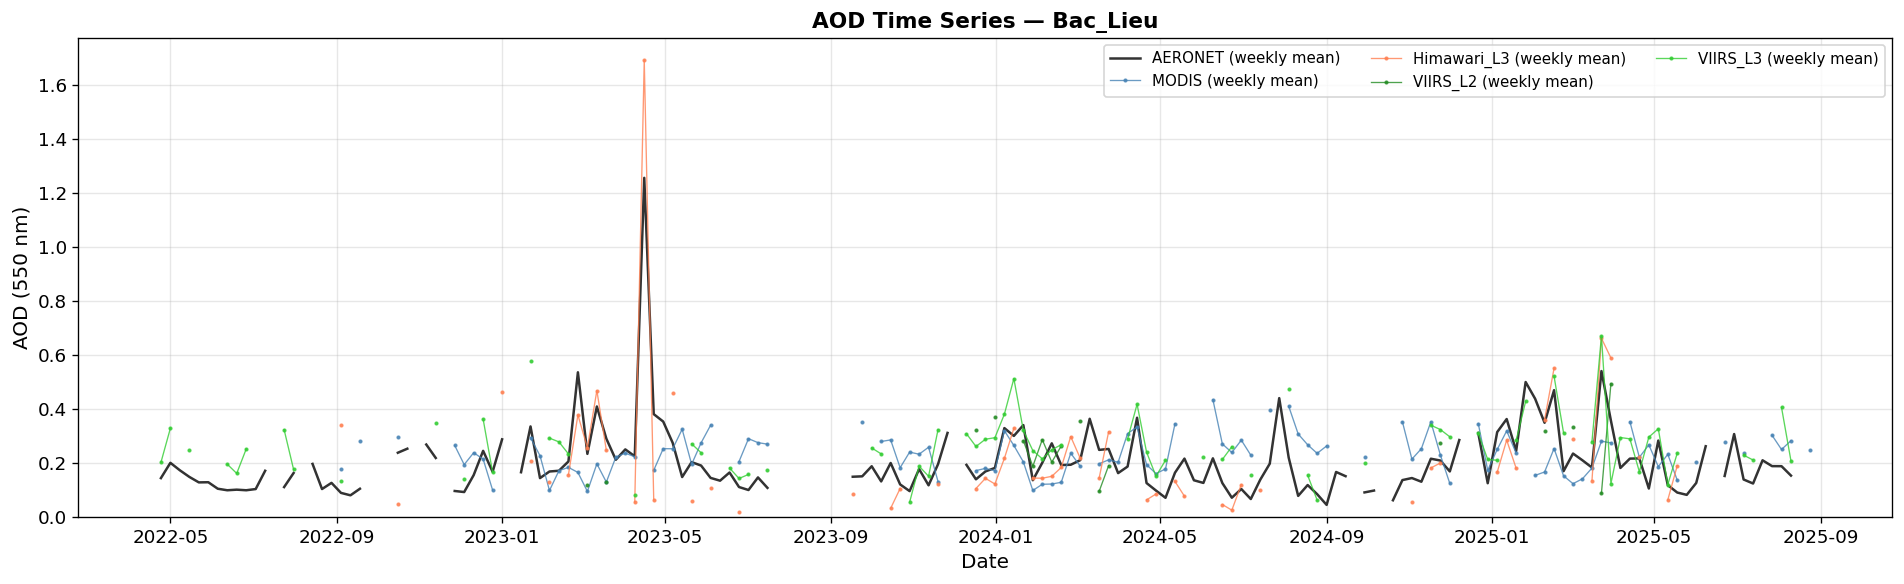

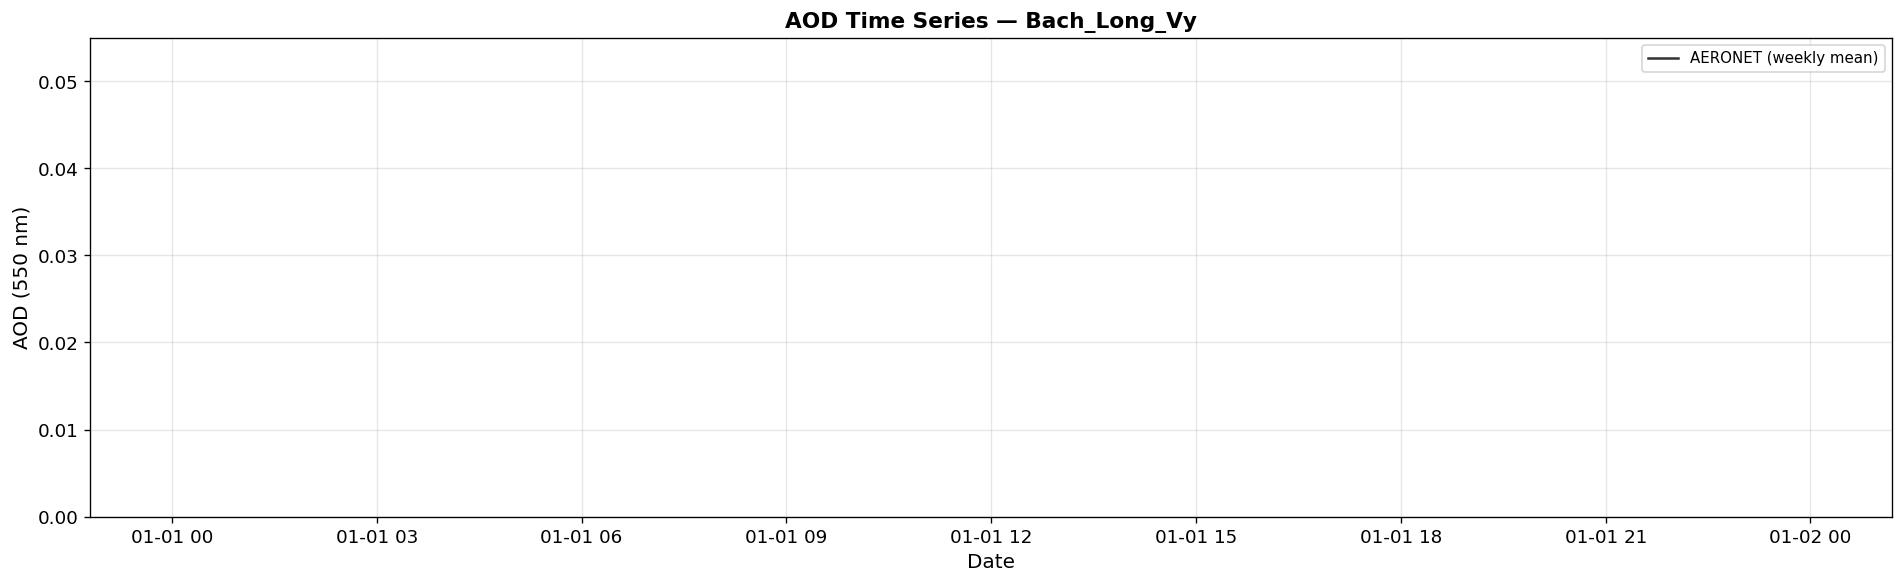

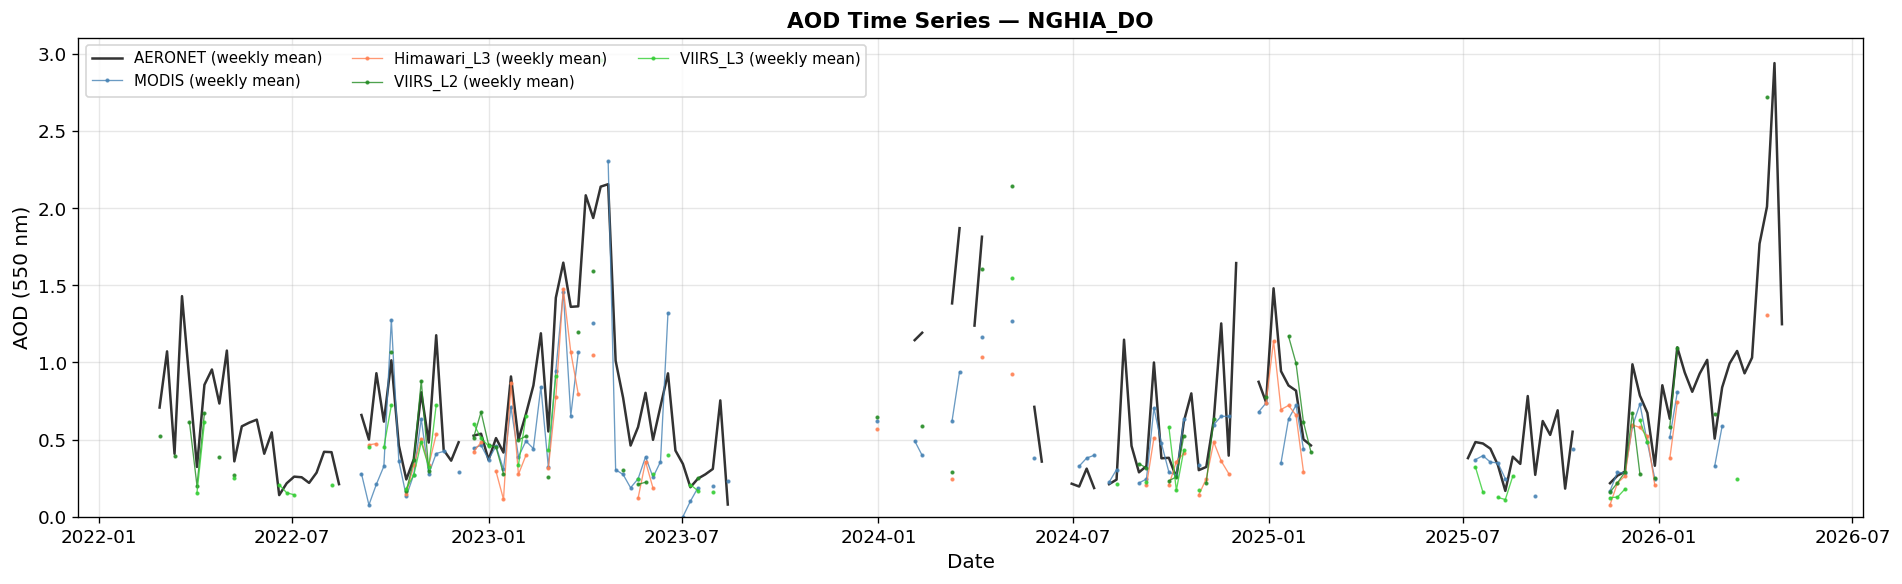

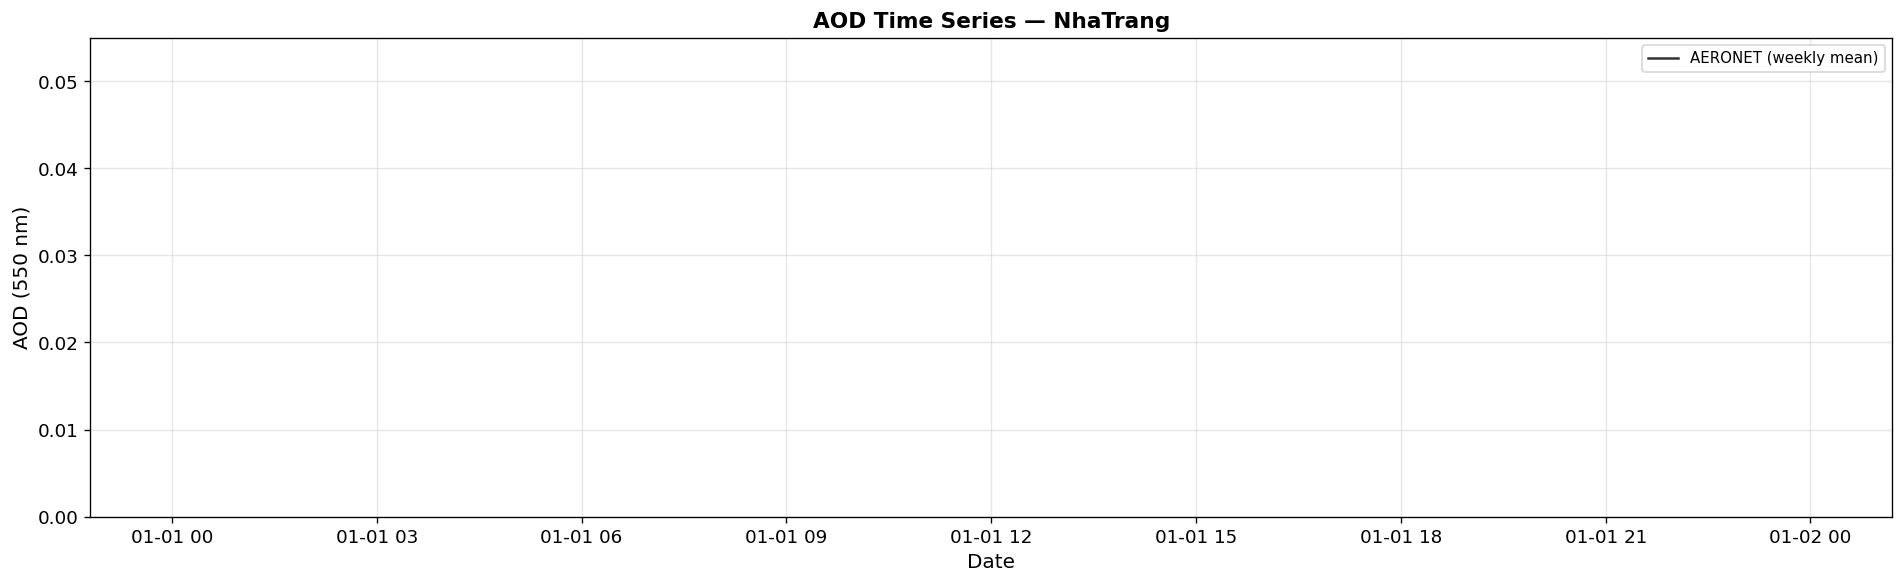

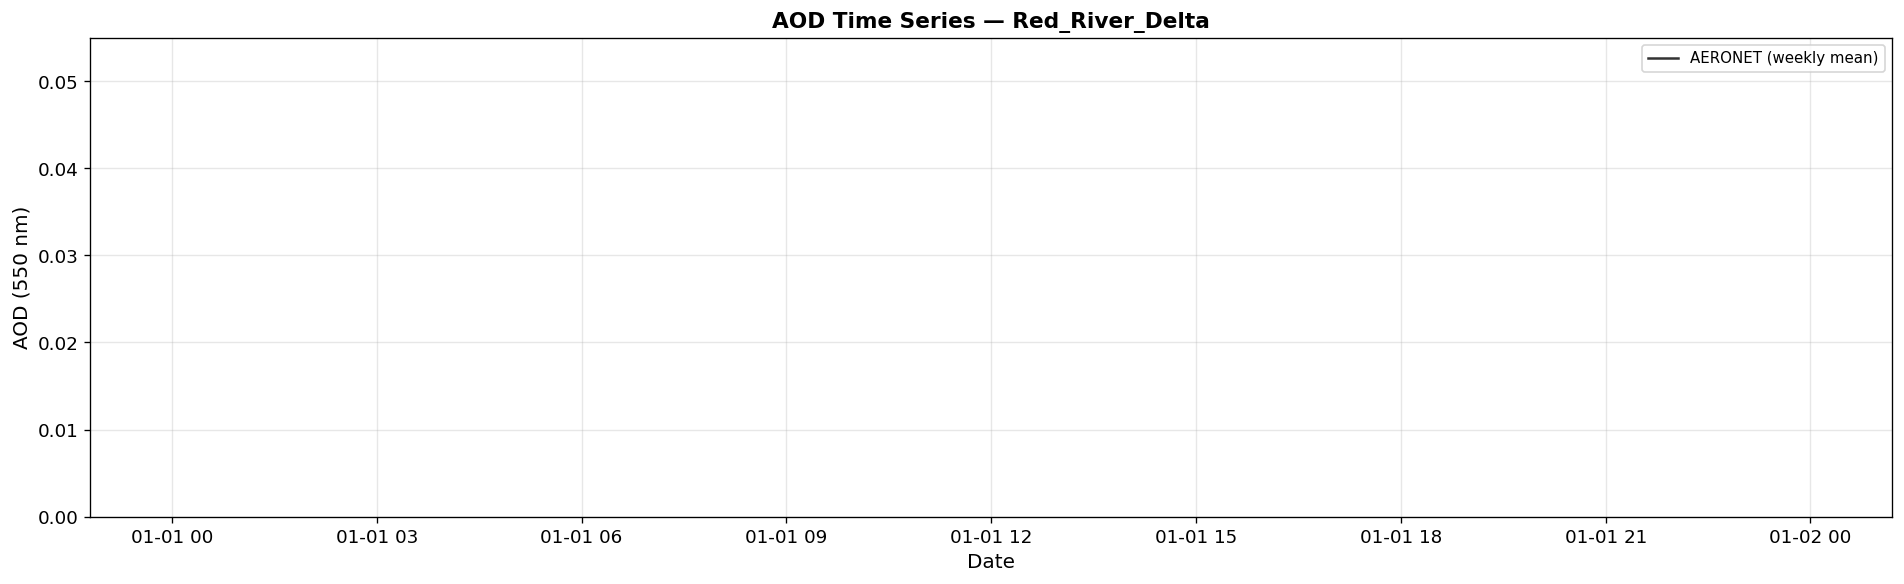

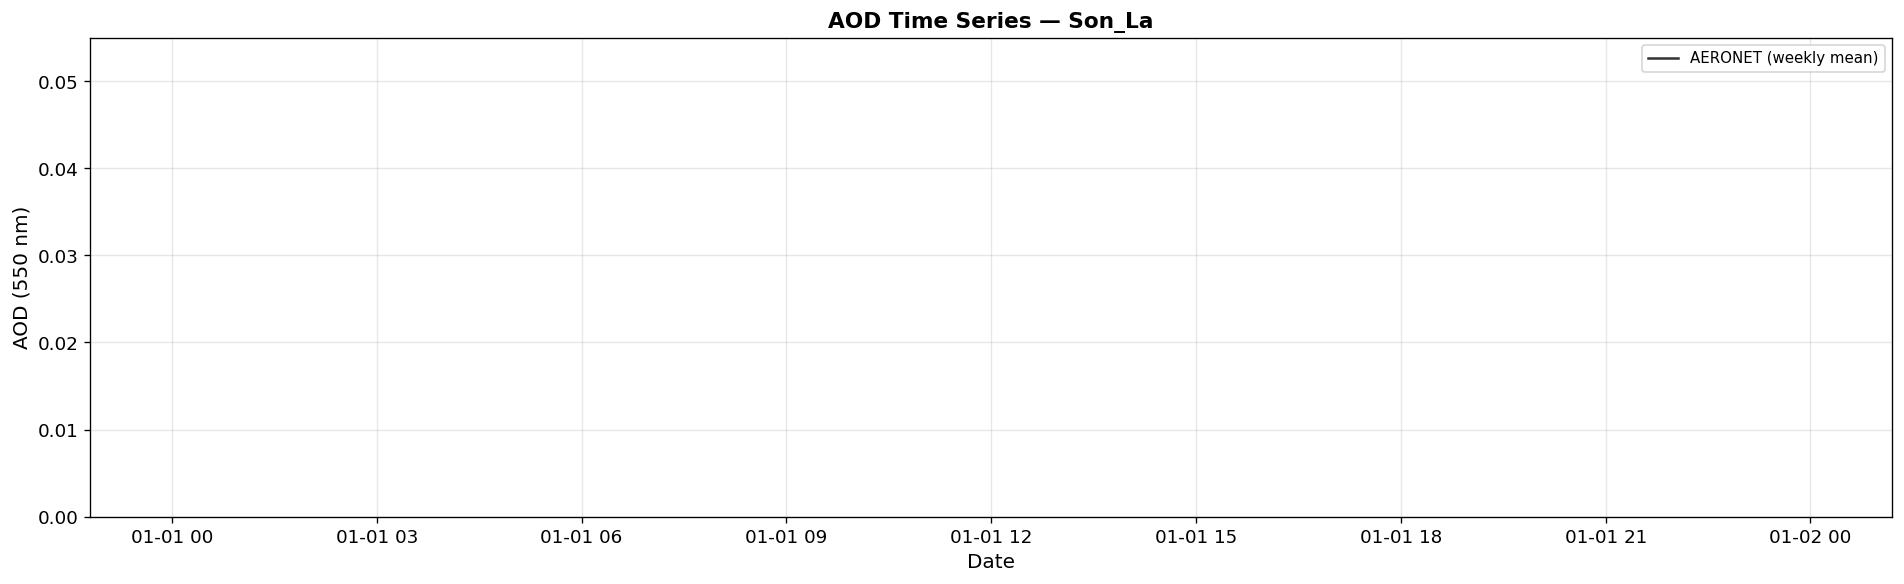

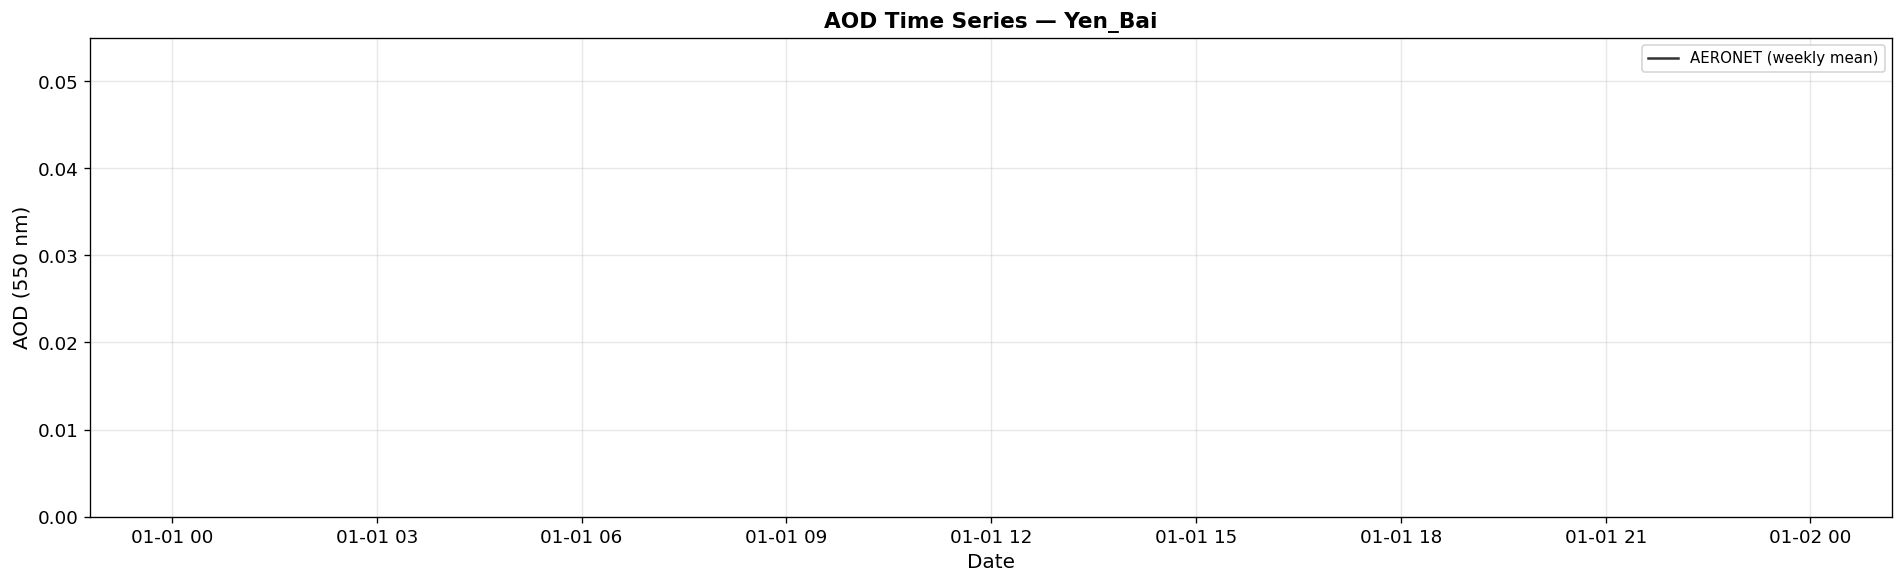

In [11]:
for aeronet_site in aeronet_station_map.keys():
    fig, ax = plt.subplots(figsize=(16, 5))

    # Plot AERONET daily average
    aero_site = aeronet[aeronet['site'] == aeronet_site].copy()
    aero_daily = aero_site.set_index('datetime').resample('W')['AOD_550'].mean()
    ax.plot(aero_daily.index, aero_daily.values, 'k-', lw=1.5, alpha=0.8, label='AERONET (weekly mean)')

    # Overlay satellite
    for sat_name, sites in sensor_sites.items():
        if aeronet_site not in sites:
            continue
        df = sites[aeronet_site]
        sat_col = f'AOD_{sat_name}'
        weekly = df.set_index('datetime').resample('W')[sat_col].mean()
        color = colors_map.get(sat_name, 'gray')
        ax.plot(weekly.index, weekly.values, color=color, marker='.', ms=3, lw=0.8,
                alpha=0.8, label=f'{sat_name} (weekly mean)')

    ax.set_xlabel('Date')
    ax.set_ylabel('AOD (550 nm)')
    ax.set_title(f'AOD Time Series — {aeronet_site}', fontweight='bold')
    ax.legend(fontsize=9, ncol=3)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

---
## 8. Sensitivity Analysis

### 8.1 Effect of Temporal Matching Window

Evaluate how the collocation time tolerance affects validation metrics. Tighter windows reduce temporal representativeness error but may reduce sample size below statistical significance thresholds.

  Bac_Lieu x MODIS: 15695 AERONET + 631 sat -> 291 matched pairs
  NGHIA_DO x MODIS: 13173 AERONET + 1461 sat -> 644 matched pairs
  Bac_Lieu x Himawari_L3: 15695 AERONET + 294 sat -> 180 matched pairs
  NGHIA_DO x Himawari_L3: 13173 AERONET + 2138 sat -> 1184 matched pairs
  Bac_Lieu x VIIRS_L2: 15695 AERONET + 35 sat -> 25 matched pairs
  NGHIA_DO x VIIRS_L2: 13173 AERONET + 464 sat -> 300 matched pairs
  Bac_Lieu x VIIRS_L3: 15695 AERONET + 578 sat -> 102 matched pairs
  NGHIA_DO x VIIRS_L3: 13173 AERONET + 1257 sat -> 222 matched pairs
  Bac_Lieu x MODIS: 15695 AERONET + 631 sat -> 335 matched pairs
  NGHIA_DO x MODIS: 13173 AERONET + 1461 sat -> 710 matched pairs
  Bac_Lieu x Himawari_L3: 15695 AERONET + 294 sat -> 199 matched pairs
  NGHIA_DO x Himawari_L3: 13173 AERONET + 2138 sat -> 1284 matched pairs
  Bac_Lieu x VIIRS_L2: 15695 AERONET + 35 sat -> 25 matched pairs
  NGHIA_DO x VIIRS_L2: 13173 AERONET + 464 sat -> 318 matched pairs
  Bac_Lieu x VIIRS_L3: 15695 AERONET + 578 sa

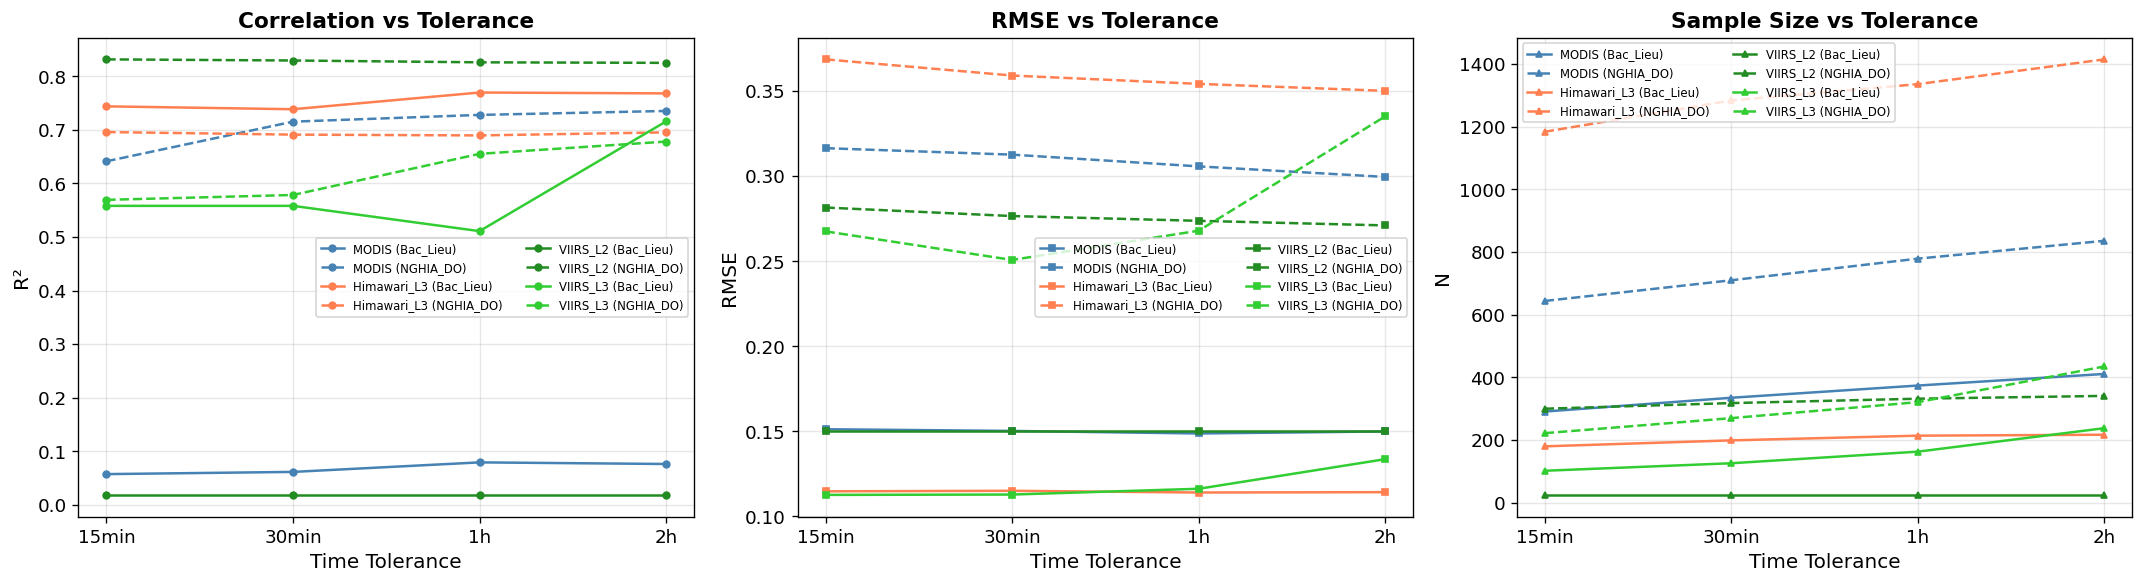


Sensitivity table:


,Sensor,Site,Tolerance,N,R2,RMSE,Bias,%EE
0,MODIS,Bac_Lieu,15min,291,0.0572,0.1512,0.0185,42.3
1,MODIS,NGHIA_DO,15min,644,0.6413,0.3164,-0.1644,52.2
2,Himawari_L3,Bac_Lieu,15min,180,0.7439,0.1147,-0.0270,67.2
3,Himawari_L3,NGHIA_DO,15min,1184,0.6959,0.3686,-0.2310,36.4
4,VIIRS_L2,Bac_Lieu,15min,25,0.0184,0.1500,0.0189,56.0
5,VIIRS_L2,NGHIA_DO,15min,300,0.8316,0.2815,0.0118,63.3
6,VIIRS_L3,Bac_Lieu,15min,102,0.5581,0.1126,0.0612,55.9
7,VIIRS_L3,NGHIA_DO,15min,222,0.5693,0.2675,-0.0680,54.1
8,MODIS,Bac_Lieu,30min,335,0.0613,0.1502,0.0153,41.8
9,MODIS,NGHIA_DO,30min,710,0.7153,0.3126,-0.1622,52.5


In [12]:
tolerances = ['15min', '30min', '1h', '2h']
sens_results = []

for tol in tolerances:
    for sat_name, sat_df in sensors.items():
        if len(sat_df) == 0:
            continue
        for aeronet_site, info in aeronet_station_map.items():
            matched_stn_names = [s['stationName'] for s in info['matched_stations']]
            result = collocate_aeronet_satellite(
                aeronet, sat_df, aeronet_site, matched_stn_names,
                tolerance=tol, sat_name=sat_name
            )
            if len(result) > 0:
                m = compute_metrics(result['AOD_AERONET'], result[f'AOD_{sat_name}'])
                if m:
                    m['Tolerance'] = tol
                    m['Sensor'] = sat_name
                    m['Site'] = aeronet_site
                    sens_results.append(m)

df_sens = pd.DataFrame(sens_results)

if len(df_sens) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for key in df_sens.apply(lambda r: f"{r['Sensor']}_{r['Site']}", axis=1).unique():
        sub = df_sens[df_sens.apply(lambda r: f"{r['Sensor']}_{r['Site']}", axis=1) == key]
        if len(sub) < 2:
            continue
        sensor = sub['Sensor'].iloc[0]
        site = sub['Site'].iloc[0]
        color = colors_map.get(sensor, 'gray')
        ls = '-' if 'Bac' in site else '--'
        label = f'{sensor} ({site})'

        axes[0].plot(range(len(sub)), sub['R2'], marker='o', color=color, ls=ls, ms=4, label=label)
        axes[1].plot(range(len(sub)), sub['RMSE'], marker='s', color=color, ls=ls, ms=4, label=label)
        axes[2].plot(range(len(sub)), sub['N'], marker='^', color=color, ls=ls, ms=4, label=label)

    for ax, ylabel, title in zip(axes, ['R\u00b2', 'RMSE', 'N'],
                                        ['Correlation vs Tolerance', 'RMSE vs Tolerance', 'Sample Size vs Tolerance']):
        ax.set_xticks(range(len(tolerances)))
        ax.set_xticklabels(tolerances)
        ax.set_xlabel('Time Tolerance')
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('\nSensitivity table:')
    display(df_sens[['Sensor', 'Site', 'Tolerance', 'N', 'R2', 'RMSE', 'Bias', '%EE']])

---
### 8.2 L2 vs L3 Product Comparison

Compare validation performance between Level-2 (swath/pixel-level) and Level-3 (gridded/aggregated) satellite products. L2 preserves spatial resolution but has less temporal coverage; L3 improves coverage through aggregation but may introduce smoothing.

In [13]:
# Compare L2 vs L3 for Himawari and VIIRS
l2l3_pairs = [
    ('Himawari_L2', 'Himawari_L3'),
    ('VIIRS_L2', 'VIIRS_L3'),
]

for l2_name, l3_name in l2l3_pairs:
    if l2_name not in sensor_sites or l3_name not in sensor_sites:
        print(f'Skipping {l2_name} vs {l3_name}: data not available')
        continue

    print(f'\n=== {l2_name} vs {l3_name} ===')

    rows = []
    for site_name in set(list(sensor_sites.get(l2_name, {}).keys()) + list(sensor_sites.get(l3_name, {}).keys())):
        for level, sname in [('L2', l2_name), ('L3', l3_name)]:
            if site_name in sensor_sites.get(sname, {}):
                df = sensor_sites[sname][site_name]
                m = compute_metrics(df['AOD_AERONET'], df[f'AOD_{sname}'])
                if m:
                    m['Level'] = level
                    m['Sensor'] = sname
                    m['Site'] = site_name
                    rows.append(m)

    if rows:
        df_l2l3 = pd.DataFrame(rows)
        display(df_l2l3[['Sensor', 'Level', 'Site', 'N', 'R2', 'RMSE', 'MAE', 'Bias', '%EE']])

Skipping Himawari_L2 vs Himawari_L3: data not available

=== VIIRS_L2 vs VIIRS_L3 ===


,Sensor,Level,Site,N,R2,RMSE,MAE,Bias,%EE
0,VIIRS_L2,L2,NGHIA_DO,318,0.8295,0.2765,0.1510,0.0090,63.5
1,VIIRS_L3,L3,NGHIA_DO,270,0.5784,0.2507,0.1562,-0.0668,54.4
2,VIIRS_L2,L2,Bac_Lieu,25,0.0184,0.1500,0.1088,0.0189,56.0
3,VIIRS_L3,L3,Bac_Lieu,126,0.5581,0.1128,0.0888,0.0653,54.8


---
## 9. Comprehensive Validation Summary

In [14]:
if all_metrics:
    df_final = pd.DataFrame(all_metrics)

    print('=' * 80)
    print('SATELLITE AOD VALIDATION AGAINST AERONET — SUMMARY')
    print(f'Time tolerance: \u00b1{TIME_TOLERANCE}')
    print(f'EE envelope: \u00b1({EE_OFFSET} + {EE_SLOPE} \u00d7 AOD_AERONET)')
    print('=' * 80)

    display(df_final[['Sensor', 'Site', 'N', 'R', 'R2', 'RMSE', 'MAE', 'Bias', 'RelBias%', '%EE', 'Slope', 'Intercept']].round(4))

    # Highlight best performer per site
    for site in df_final['Site'].unique():
        sub = df_final[df_final['Site'] == site]
        best_r2 = sub.loc[sub['R2'].idxmax()]
        best_ee = sub.loc[sub['%EE'].idxmax()]
        print(f'\n{site}:')
        print(f'  Best R\u00b2: {best_r2["Sensor"]} (R\u00b2 = {best_r2["R2"]:.3f})')
        print(f'  Best %EE: {best_ee["Sensor"]} (%EE = {best_ee["%EE"]:.1f}%)')
else:
    print('No validation results available.')

SATELLITE AOD VALIDATION AGAINST AERONET — SUMMARY
Time tolerance: ±30min
EE envelope: ±(0.05 + 0.15 × AOD_AERONET)


,Sensor,Site,N,R,R2,RMSE,MAE,Bias,RelBias%,%EE,Slope,Intercept
0,MODIS,Bac_Lieu,335,0.2476,0.0613,0.1502,0.1199,0.0153,7.34,41.8,0.1928,0.1830
1,MODIS,NGHIA_DO,710,0.8457,0.7153,0.3126,0.1949,-0.1622,-26.74,52.5,0.5923,0.0851
2,Himawari_L3,Bac_Lieu,199,0.8593,0.7385,0.1150,0.0826,-0.0299,-11.21,65.3,1.0489,-0.0429
3,Himawari_L3,NGHIA_DO,1284,0.8313,0.6911,0.3591,0.2423,-0.2258,-34.32,37.6,0.5165,0.0922
4,VIIRS_L2,Bac_Lieu,25,0.1355,0.0184,0.1500,0.1088,0.0189,8.06,56.0,0.1274,0.2231
5,VIIRS_L2,NGHIA_DO,318,0.9108,0.8295,0.2765,0.1510,0.0090,1.42,63.5,1.1263,-0.0714
6,VIIRS_L3,Bac_Lieu,126,0.7470,0.5581,0.1128,0.0888,0.0653,32.68,54.8,0.7387,0.1176
7,VIIRS_L3,NGHIA_DO,270,0.7605,0.5784,0.2507,0.1562,-0.0668,-15.09,54.4,0.8768,-0.0123



Bac_Lieu:
  Best R²: Himawari_L3 (R² = 0.739)
  Best %EE: Himawari_L3 (%EE = 65.3%)

NGHIA_DO:
  Best R²: VIIRS_L2 (R² = 0.830)
  Best %EE: VIIRS_L2 (%EE = 63.5%)


---
## 10. Discussion & Conclusions

### Key Findings

1. **MODIS validation:** Limited by small sample size at both AERONET sites (polar orbit provides only 1–2 cloud-free observations/day overlapping with AERONET). Despite this, MODIS MAIAC (MCD19A2) typically shows reasonable correlation at NGHIA_DO due to the high AOD dynamic range in Hanoi.

2. **Himawari validation:** The geostationary orbit provides much higher temporal sampling, yielding more co-located pairs. However, the 500→550 nm wavelength correction is hampered by low Ångström exponent availability (~15% of records). L3 (hourly) products tend to show higher correlation than L2 (10-minute) due to temporal averaging that reduces noise.

3. **VIIRS validation:** Similar orbit constraints to MODIS. The QA filtering is critical for removing cloud-contaminated retrievals.

4. **Site-specific behavior:**
   - **NGHIA_DO (Hanoi):** Higher mean AOD (~0.6), broader dynamic range → typically higher R but also higher RMSE
   - **Bac_Lieu:** Lower mean AOD (~0.2), narrower range → lower R but generally lower RMSE

### Limitations

- **Spatial representativeness:** Satellite data was extracted at EnviSoft station locations, not directly at AERONET coordinates. The spatial separation (5–50 km) introduces collocation uncertainty, particularly for inhomogeneous aerosol fields.
- **AERONET quality level:** Data is Level 1.5 (cloud-screened but not quality-assured). Level 2.0 would provide higher confidence but at reduced data availability.
- **Limited ground truth:** Only 2 AERONET sites in Vietnam constrains the geographic representativeness of the validation.
- **Wavelength correction:** The Ångström-based interpolation assumes a power-law spectral dependence, which may not hold for all aerosol types (e.g., coarse-mode dust).

### Recommendations
- Request AERONET Level 2.0 data when available for stricter quality assurance
- Consider deploying additional AERONET sites in Central Vietnam (validation gap)
- Investigate the spatial representativeness by comparing single-pixel vs area-averaged satellite retrievals
- For Himawari, prioritize the Merged product with available AE for wavelength correction
- Explore machine-learning-based AOD bias correction trained on the collocated AERONET dataset